# GDPR classifier reproducibility notebook

Reproduces the GDPR-coverage classifier numbers reported in `Appendix.tex` ("GDPR Classifier Training and Benchmark"):

* Table `gdpr-classifier-benchmark` — Exact-Match, micro/macro precision/recall/F1 for RoBERTa-base (ours), BERT-base-uncased and Legal-BERT, on the Rahat et al. (WPES'22) test split.
* Figure `fig1_overall_comparison` — grouped-bar overall-comparison chart for the same three models.

The notebook ends with a sanity-check cell that prints every reproduced number alongside the value reported in the paper.

## What ships in `gdpr_classifier/`

* `train.py` — single-script trainer (`AutoModelForSequenceClassification`, focal BCE, per-class threshold tuning, early stopping).
* `data/gdpr_dataset_1.2.csv` — the Rahat et al. multi-label segments (10,510 rows, 18 categories).
* `results/gdpr_*.json` — per-model evaluation output on the 200-segment test split (overall metrics + per-label P/R/F1). The notebook below reads these directly, so the trained weights are not required.

The 476 MB RoBERTa weights (`model.safetensors` + tokenizer files) ship separately on the GitHub release page; extract that tarball into `gdpr_classifier/model/` if you want to run the model on new clauses.

## 1. Setup

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS  = REPO_ROOT / 'gdpr_classifier' / 'results'
FIG_DIR  = REPO_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

roberta   = json.load(open(RESULTS / 'gdpr_roberta_results.json'))['roberta-base']
bert_base = json.load(open(RESULTS / 'gdpr_bert_base_results.json'))['bert-base-uncased']
legalbert = json.load(open(RESULTS / 'gdpr_legalbert_results.json'))['nlpaueb/legal-bert-base-uncased']

MODELS = [
    ('RoBERTa',    roberta,   '#b2182b'),
    ('BERT-base',  bert_base, '#d6604d'),
    ('Legal-BERT', legalbert, '#f4a582'),
]
for name, d, _ in MODELS:
    print(f'{name:<12s} keys: {sorted(d.keys())[:7]} ...')

RoBERTa      keys: ['avg_time_per_sample', 'epochs', 'errors', 'exact_match', 'focal_gamma', 'loss_function', 'macro_f1'] ...
BERT-base    keys: ['avg_time_per_sample', 'epochs', 'errors', 'exact_match', 'focal_gamma', 'loss_function', 'macro_f1'] ...
Legal-BERT   keys: ['avg_time_per_sample', 'epochs', 'errors', 'exact_match', 'focal_gamma', 'loss_function', 'macro_f1'] ...


## 2. Overall metrics table (paper Table `gdpr-classifier-benchmark`)

Columns: EM = exact match, μP/μR/μF1 = micro precision/recall/F1, MF1 = macro F1.

In [2]:
_LABEL = {
    'RoBERTa':   'RoBERTa-base (ours)',
    'BERT-base': 'BERT-base-uncased',
    'Legal-BERT': 'Legal-BERT',
}
print(f'{"Model":<24s}  {"EM":>6s}  {"muP":>6s}  {"muR":>6s}  {"muF1":>6s}  {"MF1":>6s}')
print('=' * 60)
for name, d, _ in MODELS:
    print(f'{_LABEL[name]:<24s}  '
          f'{d["exact_match"]:>6.3f}  '
          f'{d["micro_precision"]:>6.3f}  '
          f'{d["micro_recall"]:>6.3f}  '
          f'{d["micro_f1"]:>6.3f}  '
          f'{d["macro_f1"]:>6.3f}')

Model                         EM     muP     muR    muF1     MF1
RoBERTa-base (ours)        0.900   0.925   0.938   0.931   0.939
BERT-base-uncased          0.860   0.887   0.943   0.914   0.931
Legal-BERT                 0.845   0.880   0.914   0.897   0.920


## 3. Figure `fig1_overall_comparison`

Grouped bar chart over the five overall metrics. Reproduces `figures/bert_eval/fig1_overall_comparison.pdf` from the paper.

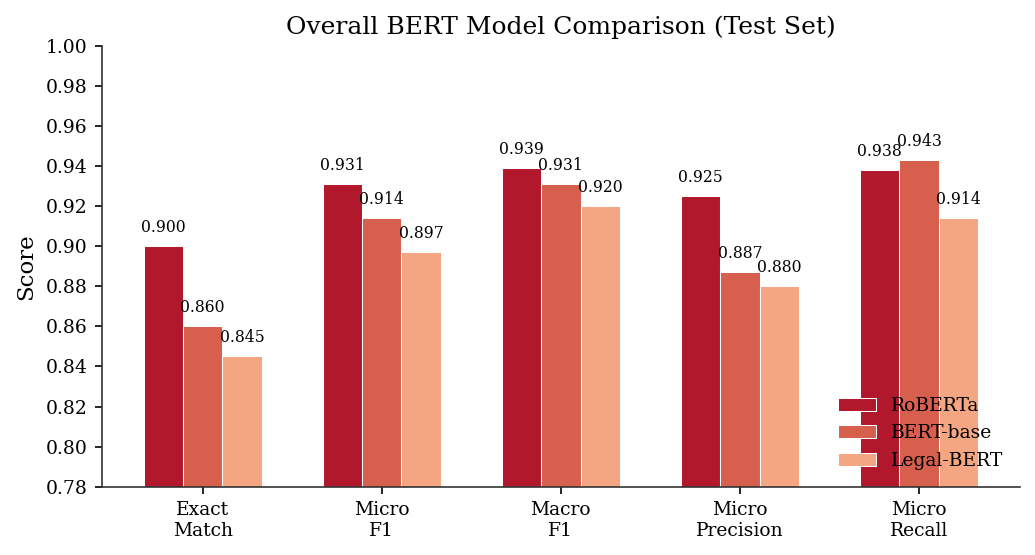

In [3]:
STYLE = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'axes.grid': False,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#333333', 'axes.linewidth': 0.8,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'figure.dpi': 150,
}
plt.rcParams.update(STYLE)

metrics = ['exact_match', 'micro_f1', 'macro_f1', 'micro_precision', 'micro_recall']
labels  = ['Exact\nMatch', 'Micro\nF1', 'Macro\nF1', 'Micro\nPrecision', 'Micro\nRecall']

x = np.arange(len(metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(7, 3.8))
for i, (name, data, color) in enumerate(MODELS):
    vals = [data[m] for m in metrics]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=name,
                  color=color, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_ylabel('Score')
ax.set_title('Overall BERT Model Comparison (Test Set)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.78, 1.0)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.02))
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_overall_comparison.pdf')
fig.savefig(FIG_DIR / 'fig1_overall_comparison.png', dpi=300)
plt.show()

## 4. Sanity check vs paper

In [4]:
_PAPER = {
    'RoBERTa':    {'EM': 0.900, 'muP': 0.925, 'muR': 0.938, 'muF1': 0.931, 'MF1': 0.939},
    'BERT-base':  {'EM': 0.860, 'muP': 0.887, 'muR': 0.943, 'muF1': 0.914, 'MF1': 0.931},
    'Legal-BERT': {'EM': 0.845, 'muP': 0.880, 'muR': 0.914, 'muF1': 0.897, 'MF1': 0.920},
}
_KEY = {'EM': 'exact_match', 'muP': 'micro_precision', 'muR': 'micro_recall',
        'muF1': 'micro_f1', 'MF1': 'macro_f1'}

ok = True
for name, paper in _PAPER.items():
    data = next(d for n, d, _ in MODELS if n == name)
    for metric_short, expected in paper.items():
        got = round(data[_KEY[metric_short]], 3)
        match = abs(got - expected) < 0.005
        print(f'  {name:<11s} {metric_short:>5s}  got={got:<6}  paper={expected:<6}  {"OK" if match else "MISMATCH"}')
        if not match:
            ok = False
print()
print('PASSED' if ok else 'FAILED')

  RoBERTa        EM  got=0.9     paper=0.9     OK
  RoBERTa       muP  got=0.925   paper=0.925   OK
  RoBERTa       muR  got=0.938   paper=0.938   OK
  RoBERTa      muF1  got=0.931   paper=0.931   OK
  RoBERTa       MF1  got=0.939   paper=0.939   OK
  BERT-base      EM  got=0.86    paper=0.86    OK
  BERT-base     muP  got=0.887   paper=0.887   OK
  BERT-base     muR  got=0.943   paper=0.943   OK
  BERT-base    muF1  got=0.914   paper=0.914   OK
  BERT-base     MF1  got=0.931   paper=0.931   OK
  Legal-BERT     EM  got=0.845   paper=0.845   OK
  Legal-BERT    muP  got=0.88    paper=0.88    OK
  Legal-BERT    muR  got=0.914   paper=0.914   OK
  Legal-BERT   muF1  got=0.897   paper=0.897   OK
  Legal-BERT    MF1  got=0.92    paper=0.92    OK

PASSED
